# LogisticsLab Jupyters Notebook
Das Notebook ist für ein einfacheres Verständnis des Codes für Aufgabe 1 aus dem LogisticsLab Kurs WiSe25/26
- Autor: Anh Le Xuan

## Imports/relative Pfade und Daten einlesen

Die Funktion `read_txt_files()` liest:
- Maschinenpositionen (`machine_positions.txt`)
- Transportanforderungen (`transport_demand.txt`)
- kleiner Plot der Aufgabe für bessere Einordnung 

Die Dateien liegen im Unterordner `data/` und enthalten Semikolon-separierte Werte.


In [105]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.display import display


# relative Pfade
git_dir = os.getcwd()
data_dir = os.path.join(git_dir, '../data')
machine_positions_path = os.path.join(data_dir, "machine_positions.txt")
transport_demand_path = os.path.join(data_dir, "transport_demand.txt")

def read_txt_files(display_dataframes=False):
  machine_positions = pd.read_csv(machine_positions_path, sep=r";", names =["machine_id", "x", "y"], header=0)
  transport_demand = pd.read_csv(transport_demand_path, sep=";")
  transport_demand["id"] = transport_demand.index + 1
  transport_demand = transport_demand[["id", "start", "dest", "number"]] # sortiert um, da id am Ende war
  if display_dataframes:
     display(machine_positions.style.hide(axis="index"))
     display(transport_demand.loc[:9].style.hide(axis="index"))
  return machine_positions, transport_demand

machine_positions, transport_demand = read_txt_files(display_dataframes=True)



machine_id,x,y
1,30,5
2,30,35
3,60,35
4,5,30
5,10,30
6,40,30
7,30,20
8,20,35
9,20,5
10,60,10


id,start,dest,number
1,1,2,7
2,1,3,1
3,1,4,1
4,1,5,9
5,1,6,1
6,1,7,8
7,1,8,9
8,1,9,2
9,1,10,7
10,2,1,5


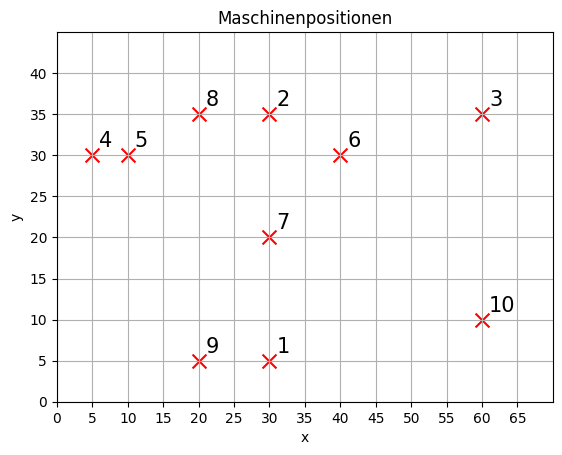

In [106]:
def plot_machine_positions():
  machine_positions, _ = read_txt_files()
  ids = machine_positions["machine_id"].values
  x = machine_positions["x"].values
  y = machine_positions["y"].values
  plt.scatter(x, y, s=100, c='red', marker='x')
  plt.xlabel("x")
  plt.ylabel("y")
  plt.xlim([0, 70])
  plt.ylim([0, 45])
  plt.xticks(np.arange(0, 70, 5))
  plt.yticks(np.arange(0, 45, 5))
  plt.title("Maschinenpositionen")
  plt.grid()
  for id, xi, yi in zip(ids, x, y):
      plt.text(xi + 1, yi + 1, id, fontsize=15)
  plt.show()

plot_machine_positions()


## Hilfsfunktionen

In [107]:
def decrease_transport_demand(start_machine, dest_machine, amount=1):
  #transport_demand = get_transport_demands()
  condition = (transport_demand["start"] == start_machine) & (transport_demand["dest"] == dest_machine) # Zeile bei der es True ist
  transport_demand.loc[condition, "number"] -= amount

def calculate_total_transport_demands():
  #transport_demand = get_transport_demands()
  total_demands = transport_demand["number"].sum()
  return total_demands

def check_if_transport_possible(start_machine, dest_machine):
  condition = (transport_demand["start"] == start_machine) & (transport_demand["dest"] == dest_machine)

  demand_row = transport_demand.loc[condition]
  if not demand_row.empty and demand_row.iloc[0]["number"] > 0:
    return True
  else:
    return False


## Euklidische Distanz Matrix

In [108]:
def calculate_distances_between(m1, m2, get_distance=True, display_matrix=False, get_matrix=False):
  cross = machine_positions.merge(machine_positions, how="cross", suffixes=("_i", "_j")) # Kreuzprodukt der Maschinenpositionen
  cross["dist"] = np.sqrt((cross["x_i"] - cross["x_j"])**2 + (cross["y_i"] - cross["y_j"])**2) # euklidische Distanz
  dist_matrix = cross.pivot(index="machine_id_i", columns="machine_id_j", values="dist") # Umwandlung in Matrixform
  dist_matrix = round(dist_matrix, 2)
  if display_matrix:
    display(dist_matrix)
  if get_matrix:
    return dist_matrix
  if get_distance:
    return dist_matrix.loc[m1, m2]

_ = calculate_distances_between(1, 2, display_matrix=True) # dummy
print(f"Zum Beispiel ist die Distanz zwischen Maschine 1 und 2: d12 = {_} LE.")

machine_id_j,1,2,3,4,5,6,7,8,9,10
machine_id_i,,,,,,,,,,
1,0.00,30.00,42.43,35.36,32.02,26.93,15.00,31.62,10.00,30.41
2,30.00,0.00,30.00,25.50,20.62,11.18,15.00,10.00,31.62,39.05
3,42.43,30.00,0.00,55.23,50.25,20.62,33.54,40.00,50.00,25.00
4,35.36,25.50,55.23,0.00,5.00,35.00,26.93,15.81,29.15,58.52
5,32.02,20.62,50.25,5.00,0.00,30.00,22.36,11.18,26.93,53.85
6,26.93,11.18,20.62,35.00,30.00,0.00,14.14,20.62,32.02,28.28
7,15.00,15.00,33.54,26.93,22.36,14.14,0.00,18.03,18.03,31.62
8,31.62,10.00,40.00,15.81,11.18,20.62,18.03,0.00,30.00,47.17
9,10.00,31.62,50.00,29.15,26.93,32.02,18.03,30.00,0.00,40.31


Zum Beispiel ist die Distanz zwischen Maschine 1 und 2: d12 = 30.0 LE.


## Funktion von einer Maschine den kürzesten Weg zur nächsten und überprüfe ob dieser noch Transport Demands, sonst nehme die nächste

In [ ]:
def find_next_machine(start_machine, display_text=False):
  matrix = calculate_distances_between(1, 1, get_matrix=True)
  col = matrix.loc[start_machine]
  filtered = col[col != 0] # 0 rausfiltern
  sorted_distances = filtered.sort_values() # Sortiere nach kleinster Distanz
  print(f"Das ist sorted_distances: \n{sorted_distances}")
  for next_machine, dist in sorted_distances.items():
      if check_if_transport_possible(start_machine, next_machine):
          if display_text:
            print(f"Für Maschine {start_machine} ist {next_machine} die beste Maschien mit der Distanz: {dist} LE.")
          return next_machine
  return None
#
find_next_machine(1, display_text=True)




Das ist sorted_distances: 
machine_id_j
9     10.00
7     15.00
6     26.93
2     30.00
10    30.41
8     31.62
5     32.02
4     35.36
3     42.43
Name: 1, dtype: float64
Für Maschine 1 ist 2 die beste Maschien mit der Distanz: 30.0 LE.
False


In [110]:
schedule = pd.DataFrame(columns=["VehicleId", "Location", "unload", "load"])
count = 0
sum_of_transports_demands = calculate_total_transport_demands()


def calculate_best_route(carID, start_machine, unload, load):
  global count
  global sum_of_transports_demands
  if sum_of_transports_demands > 200:
    schedule.loc[count] = [carID, start_machine, unload, load]
    routes_for_start_machine = transport_demand[transport_demand["start"] == start_machine] # alle Routen die am start_machine beginnen
    num_demands = len(routes_for_start_machine)
    distances = {}
    for i in range(num_demands):
      dest_machine = routes_for_start_machine.iloc[i]["dest"]
      if calculate_distances_between(start_machine, dest_machine) != 0 and check_if_transport_possible(start_machine, dest_machine): # falls start = 1 und dest = 1, was aber keinen Sinn ergibt, aber trotzdem Fehler auffangen
        distances[dest_machine] = calculate_distances_between(start_machine, dest_machine)
    try:
      #least_distance = min(distances.values())
      best_machine = min(distances, key=distances.get)
    except ValueError:
      transport_demand.to_csv("test.csv", index=False)
      print(start_machine)
    decrease_transport_demand(start_machine, best_machine)

    count += 1
    sum_of_transports_demands -= 1
    return calculate_best_route(carID, best_machine, unload, load)
  else:
    print("All transport demands completed.")
    print(schedule)

calculate_best_route(1, 1, 1, 1)

6


UnboundLocalError: cannot access local variable 'best_machine' where it is not associated with a value